In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
# Using encoding='latin1' because Superstore data often has special characters
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# 2. Date Conversion (The 'Strict' Requirement for Supply Chain)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 3. Create the 'Profit Margin %' column
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

# 4. The Verification Check
print("--- Data Loaded Successfully ---")
print(f"Total Transactions: {len(df)}")
print("\nAverage Profit Margin by Category:")
print(df.groupby('Category')['Profit Margin %'].mean())

Matplotlib is building the font cache; this may take a moment.


--- Data Loaded Successfully ---
Total Transactions: 9994

Average Profit Margin by Category:
Category
Furniture           3.878326
Office Supplies    13.803032
Technology         15.613812
Name: Profit Margin %, dtype: float64


--- Furniture Profit Margin by Region ---
Region
Central   -18.583763
East        9.238869
West        9.772291
South      14.166114
Name: Profit Margin %, dtype: float64


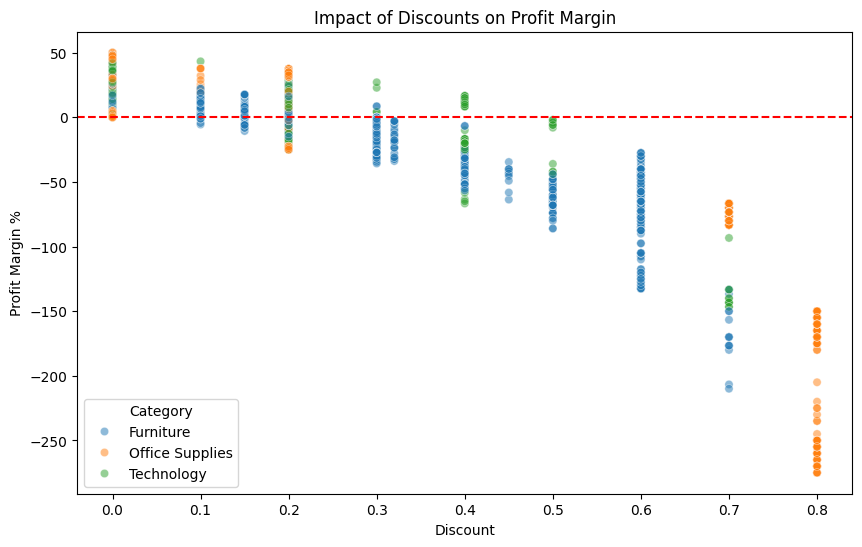


Total Loss from Unprofitable Orders: $156,131.29
Number of Loss-making Orders: 1871


In [4]:
# 1. Regional Breakdown of Furniture
furniture_df = df[df['Category'] == 'Furniture']
regional_furniture = furniture_df.groupby('Region')['Profit Margin %'].mean().sort_values()

print("--- Furniture Profit Margin by Region ---")
print(regional_furniture)

# 2. Visualization: The "Discount Trap"
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit Margin %', hue='Category', alpha=0.5)
plt.axhline(0, color='red', linestyle='--') # The "Break-even" line
plt.title('Impact of Discounts on Profit Margin')

# 3. Save this chart for your GitHub Portfolio
plt.savefig('discount_impact.png')
plt.show()

# 4. Quantify the Loss (The "₹156K" Logic)
loss_making_orders = df[df['Profit'] < 0]
total_loss = loss_making_orders['Profit'].sum()
print(f"\nTotal Loss from Unprofitable Orders: ${abs(total_loss):,.2f}")
print(f"Number of Loss-making Orders: {len(loss_making_orders)}")


In [5]:
import sqlite3

# 1. Connect to a temporary SQL database
conn = sqlite3.connect('superstore.db')

# 2. Push your cleaned dataframe into an SQL table named 'orders'
df.to_sql('orders', conn, if_exists='replace', index=False)

# 3. Test the connection: Select the top 5 rows using SQL
test_query = "SELECT [Order ID], [Customer Name], Sales, Profit FROM orders LIMIT 5"
pd.read_sql(test_query, conn)

,Order ID,Customer Name,Sales,Profit
0,CA-2016-152156,Claire Gute,261.9600,41.9136
1,CA-2016-152156,Claire Gute,731.9400,219.5820
2,CA-2016-138688,Darrin Van Huff,14.6200,6.8714
3,US-2015-108966,Sean O'Donnell,957.5775,-383.0310
4,US-2015-108966,Sean O'Donnell,22.3680,2.5164


In [6]:
pareto_query = """
WITH ProductRevenue AS (
    SELECT 
        [Sub-Category], 
        SUM(Sales) as TotalSales
    FROM orders
    GROUP BY 1
),
CalculatedPareto AS (
    SELECT 
        *,
        SUM(TotalSales) OVER(ORDER BY TotalSales DESC) as CumulativeSales,
        SUM(TotalSales) OVER() as GrandTotal
    FROM ProductRevenue
)
SELECT 
    [Sub-Category], 
    TotalSales,
    ROUND((CumulativeSales / GrandTotal) * 100, 2) as Running_Percentage
FROM CalculatedPareto
ORDER BY TotalSales DESC;
"""

pareto_results = pd.read_sql(pareto_query, conn)
print("--- Pareto Analysis (Revenue Concentration) ---")
print(pareto_results)

--- Pareto Analysis (Revenue Concentration) ---
   Sub-Category   TotalSales  Running_Percentage
0        Phones  330007.0540               14.37
1        Chairs  328449.1030               28.66
2       Storage  223843.6080               38.41
3        Tables  206965.5320               47.42
4       Binders  203412.7330               56.27
5      Machines  189238.6310               64.51
6   Accessories  167380.3180               71.80
7       Copiers  149528.0300               78.31
8     Bookcases  114879.9963               83.31
9    Appliances  107532.1610               87.99
10  Furnishings   91705.1640               91.98
11        Paper   78479.2060               95.40
12     Supplies   46673.5380               97.43
13          Art   27118.7920               98.61
14    Envelopes   16476.4020               99.32
15       Labels   12486.3120               99.87
16    Fasteners    3024.2800              100.00


In [7]:
loss_query = """
SELECT 
    Region, 
    Category, 
    SUM(Sales) AS Total_Sales, 
    SUM(Profit) AS Total_Profit,
    ROUND(AVG(Discount) * 100, 2) AS Avg_Discount_Percent
FROM orders
GROUP BY Region, Category
HAVING SUM(Profit) < 0
ORDER BY Total_Profit ASC;
"""

loss_results = pd.read_sql(loss_query, conn)
print("--- Loss-Making Segments (The 'Money Bleeders') ---")
print(loss_results)

--- Loss-Making Segments (The 'Money Bleeders') ---
    Region   Category  Total_Sales  Total_Profit  Avg_Discount_Percent
0  Central  Furniture  163797.1638    -2871.0494                 29.74


In [8]:
yoy_query = """
WITH YearlySales AS (
    SELECT 
        STRFTIME('%Y', [Order Date]) AS Year,
        SUM(Sales) AS Revenue
    FROM orders
    GROUP BY 1
)
SELECT 
    Year,
    Revenue,
    LAG(Revenue) OVER (ORDER BY Year) AS Previous_Year_Revenue,
    ROUND(((Revenue - LAG(Revenue) OVER (ORDER BY Year)) / LAG(Revenue) OVER (ORDER BY Year)) * 100, 2) AS Growth_Pct
FROM YearlySales;
"""

yoy_results = pd.read_sql(yoy_query, conn)
print("\n--- Year-over-Year Revenue Growth ---")
print(yoy_results)


--- Year-over-Year Revenue Growth ---
   Year      Revenue  Previous_Year_Revenue  Growth_Pct
0  2014  484247.4981                    NaN         NaN
1  2015  470532.5090            484247.4981       -2.83
2  2016  609205.5980            470532.5090       29.47
3  2017  733215.2552            609205.5980       20.36


In [9]:
# Save the cleaned data for Power BI
df.to_csv('Superstore_Cleaned_Analytical.csv', index=False)
print("File Saved! You are ready for Phase 3.")

File Saved! You are ready for Phase 3.


# Phase 1: Data Ingestion & Initial Health Check